In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("C:/Users/kolhe/Downloads/Social_Network_Ads.csv")


In [5]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [8]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [10]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [11]:
X = df[['Age','EstimatedSalary','Gender']]
y = df['Purchased']

In [12]:
print("Covariance Matrix:")
print(np.cov(X.T))

Covariance Matrix:
[[ 1.09890702e+02  5.54873810e+04 -3.86917293e-01]
 [ 5.54873810e+04  1.16260270e+09 -1.03140351e+03]
 [-3.86917293e-01 -1.03140351e+03  2.50526316e-01]]


In [13]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=0)

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

In [15]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(xtrain, ytrain)

LogisticRegression()

In [16]:
y_pred = logreg.predict(xtest)

In [17]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(ytest, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9


In [18]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
cm = confusion_matrix(ytest, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[65  3]
 [ 7 25]]


In [19]:
precision = precision_score(ytest, y_pred)
print("Precision:", precision)

Precision: 0.8928571428571429


In [20]:
recall = recall_score(ytest, y_pred)
print("Recall:", recall)

Recall: 0.78125


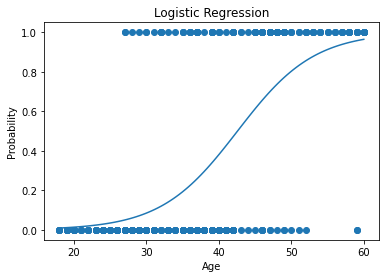

In [21]:
X = df[['Age']].values
y = df['Purchased'].values
model = LogisticRegression()
model.fit(X, y)
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_prob = model.predict_proba(X_test)[:,1]
plt.scatter(X, y)   
plt.plot(X_test, y_prob) 
plt.xlabel("Age")
plt.ylabel("Probability")
plt.title("Logistic Regression")
plt.show()

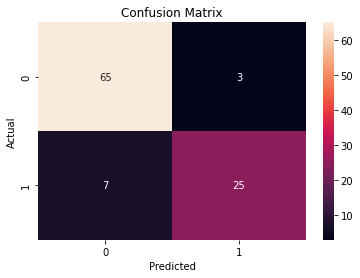

In [22]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()